<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week8_Banerjee_Jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
204,87930,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,B
70,859575,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,...,26.58,165.90,1866.0,0.11930,0.2336,0.2687,0.17890,0.2551,0.06589,M
131,8670,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,...,26.00,124.90,1156.0,0.15460,0.2394,0.3791,0.15140,0.2837,0.08019,M
431,907915,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,...,22.91,89.61,515.8,0.14500,0.2629,0.2403,0.07370,0.2556,0.09359,B
540,921385,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,...,19.68,78.78,457.8,0.13450,0.2118,0.1797,0.06918,0.2329,0.08134,B
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.8681,0.9387,0.26500,0.4087,0.12400,M
369,9012000,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.24480,0.15010,0.1824,...,25.80,195.00,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574,M
29,853201,17.57,15.05,115.00,955.1,0.09847,0.11570,0.09875,0.07953,0.1739,...,19.52,134.90,1227.0,0.12550,0.2812,0.2489,0.14560,0.2756,0.07919,M
81,8611161,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,...,23.19,96.66,614.9,0.15360,0.4791,0.4858,0.17080,0.3527,0.10160,B
477,911673,13.90,16.62,88.97,599.4,0.06828,0.05319,0.02224,0.01339,0.1813,...,21.80,101.20,718.9,0.09384,0.2006,0.1384,0.06222,0.2679,0.07698,B


In [3]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [4]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Target and Features
X = df_BreastCancer.drop(["Diagnosis", "ID"], axis=1)
y = df_BreastCancer["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Distance Metrics to Compare
metrics = {
    "Euclidean": "euclidean",
    "Manhattan": "manhattan",
    "Minkowski": "minkowski"
}

# Train and Evaluate
results = []

for metric_name, metric in metrics.items():

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(
            n_neighbors=5,
            metric=metric
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([metric_name, accuracy])

    print("="*60)
    print(metric_name)
    print("="*60)

    print("Accuracy:", round(accuracy,4))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))


results_df = pd.DataFrame(
    results,
    columns=["Distance Metric","Accuracy"]
)

print("\nSummary")
print(results_df.sort_values(by="Accuracy", ascending=False))


Euclidean
Accuracy: 0.979

Confusion Matrix
[[50  3]
 [ 0 90]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        53
           1       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143

Manhattan
Accuracy: 0.965

Confusion Matrix
[[49  4]
 [ 1 89]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        53
           1       0.96      0.99      0.97        90

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

Minkowski
Accuracy: 0.979

Confusion Matrix
[[50  3]
 [ 0 90]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.94

In [5]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": range(1,21),
    "knn__metric": ["euclidean","manhattan","minkowski"],
    "knn__weights": ["uniform","distance"]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(grid.best_score_)

Best Parameters:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}

Best CV Accuracy:
0.9670861833105336


In [13]:

best_model = grid.best_estimator_

In [6]:
from sklearn.metrics import accuracy_score

# Predictions
train_pred = grid.best_estimator_.predict(X_train)
test_pred = grid.best_estimator_.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy :", round(train_acc, 4))
print("Testing Accuracy  :", round(test_acc, 4))
print("Difference        :", round(train_acc - test_acc, 4))

Training Accuracy : 0.9695
Testing Accuracy  : 0.965
Difference        : 0.0044


In [7]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    grid.best_estimator_,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Mean CV Accuracy :", np.mean(cv_scores))
print("Test Accuracy    :", test_acc)

Mean CV Accuracy : 0.9666356155876417
Test Accuracy    : 0.965034965034965


In [8]:
from sklearn.metrics import classification_report

print("Training Performance")
print(classification_report(y_train, train_pred))

print("Testing Performance")
print(classification_report(y_test, test_pred))

Training Performance
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       159
           1       0.96      0.99      0.98       267

    accuracy                           0.97       426
   macro avg       0.97      0.96      0.97       426
weighted avg       0.97      0.97      0.97       426

Testing Performance
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.95      1.00      0.97        90

    accuracy                           0.97       143
   macro avg       0.97      0.95      0.96       143
weighted avg       0.97      0.97      0.96       143



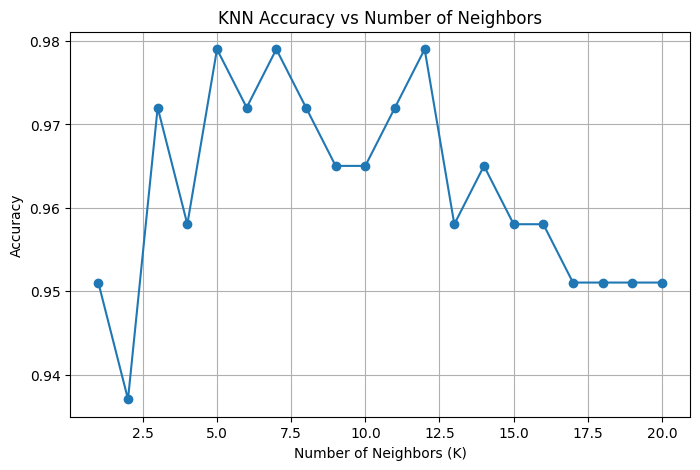

In [10]:
import matplotlib.pyplot as plt
#KNN Accuracy vs Number of Neighbors chart
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs Number of Neighbors")
plt.grid(True)
plt.show()

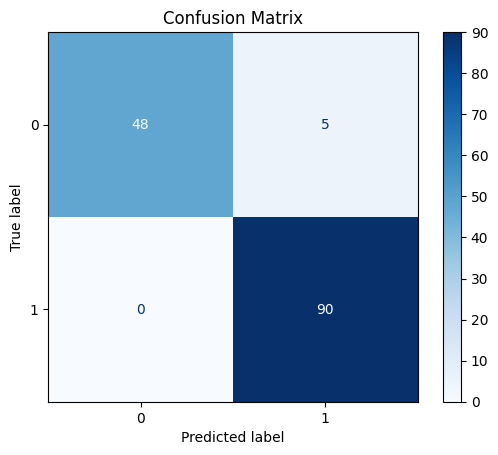

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

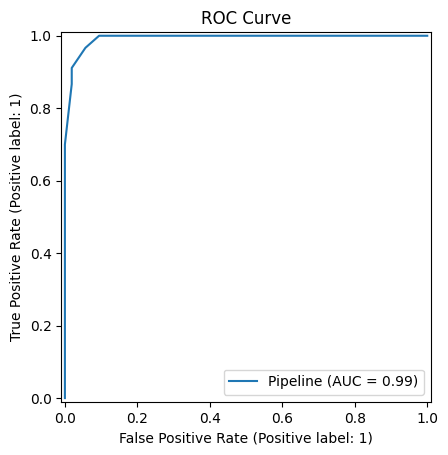

In [15]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

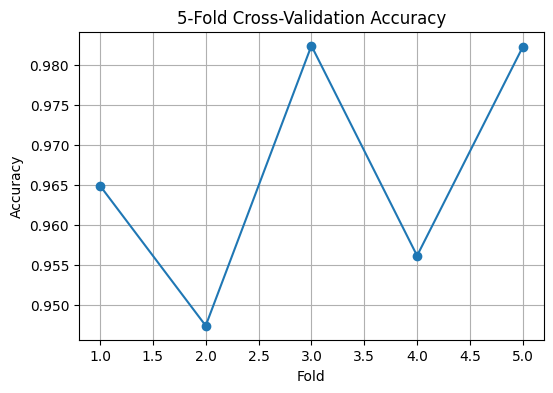

In [16]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

plt.figure(figsize=(6,4))
plt.plot(range(1,6), cv_scores, marker='o')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")
plt.grid(True)
plt.show()

In [22]:
df_BreastCancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   radius1             569 non-null    float64
 2   texture1            569 non-null    float64
 3   perimeter1          569 non-null    float64
 4   area1               569 non-null    float64
 5   smoothness1         569 non-null    float64
 6   compactness1        569 non-null    float64
 7   concavity1          569 non-null    float64
 8   concave_points1     569 non-null    float64
 9   symmetry1           569 non-null    float64
 10  fractal_dimension1  569 non-null    float64
 11  radius2             569 non-null    float64
 12  texture2            569 non-null    float64
 13  perimeter2          569 non-null    float64
 14  area2               569 non-null    float64
 15  smoothness2         569 non-null    float64
 16  compactn

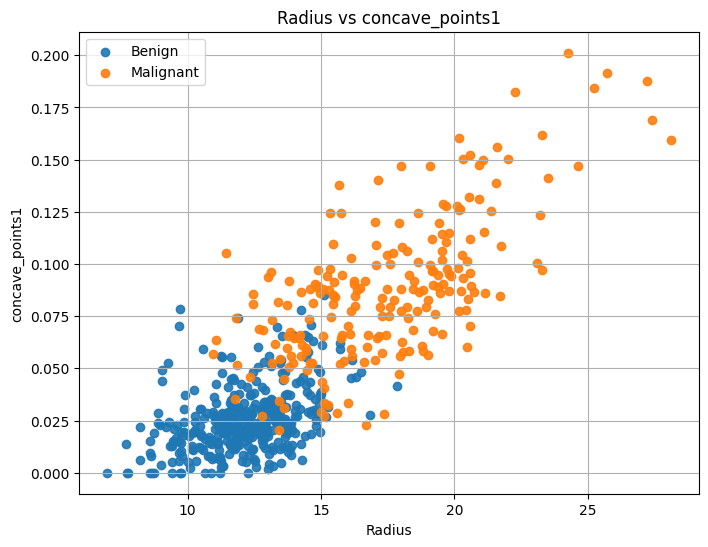

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_BreastCancer[df_BreastCancer["Diagnosis"]==1]["radius1"],
    df_BreastCancer[df_BreastCancer["Diagnosis"]==1]["concave_points1"],
    label="Benign",
    alpha=0.9
)

plt.scatter(
    df_BreastCancer[df_BreastCancer["Diagnosis"]==0]["radius1"],
    df_BreastCancer[df_BreastCancer["Diagnosis"]==0]["concave_points1"],
    label="Malignant",
    alpha=0.9
)

plt.xlabel("Radius")
plt.ylabel("concave_points1")
plt.title("Radius vs concave_points1")
plt.legend()
plt.grid(True)

plt.show()